In [1]:
import os

print(os.listdir("dataset"))


['.ipynb_checkpoints', 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
import os

for folder in os.listdir("dataset"):
    print(folder, ":", len(os.listdir("dataset/" + folder)))

.ipynb_checkpoints : 0
cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


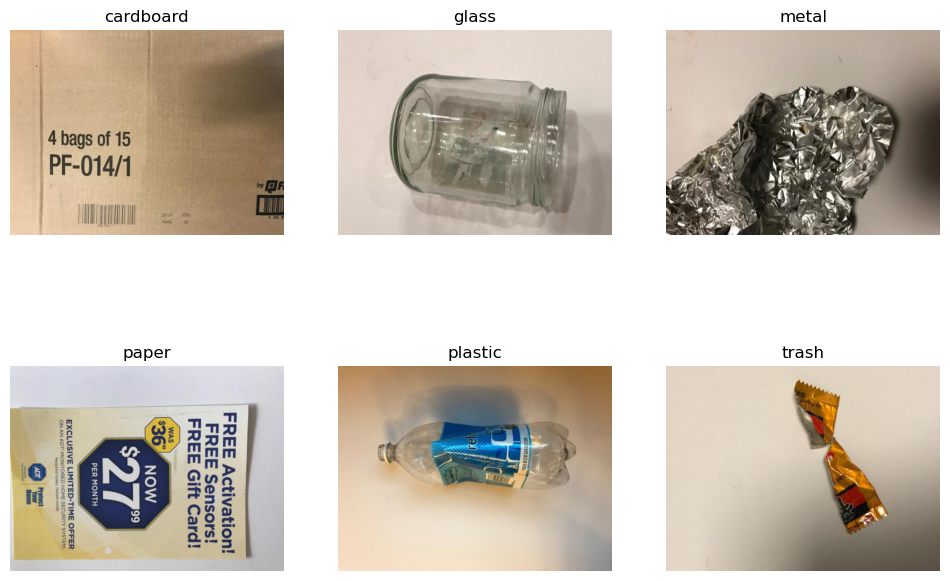

In [9]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    image_name = random.choice(os.listdir(f"dataset/{category}"))
    image_path = f"dataset/{category}/{image_name}"

    img = mpimg.imread(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

In [11]:
total = 0

for folder in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]:
    total += len(os.listdir(f"dataset/{folder}"))

print("Total Images:", total)

Total Images: 2527


In [15]:
from PIL import Image

img_path = "dataset/cardboard/" + os.listdir("dataset/cardboard")[0]

img = Image.open(img_path)

print("Image Size:", img.size)

Image Size: (512, 384)


In [18]:
from PIL import Image

sizes = set()

for folder in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]:
    for image in os.listdir(f"dataset/{folder}"):
        img = Image.open(f"dataset/{folder}/{image}")
        sizes.add(img.size)

print("Number of unique image sizes:", len(sizes))
print("Some sizes:", list(sizes)[:10])

Number of unique image sizes: 1
Some sizes: [(512, 384)]


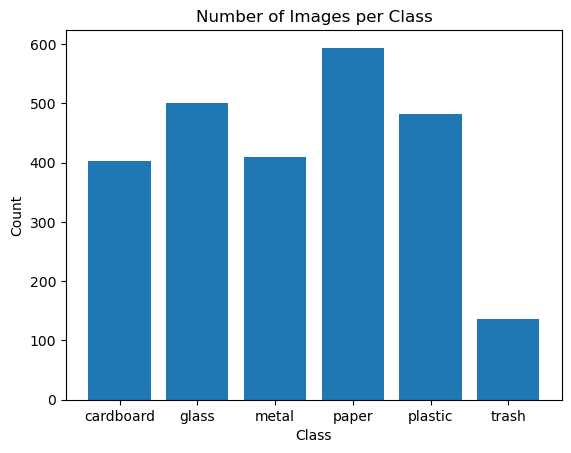

In [20]:
categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

counts = []

for category in categories:
    counts.append(len(os.listdir(f"dataset/{category}")))

plt.bar(categories, counts)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

print("sklearn imported successfully")

sklearn imported successfully


In [24]:
categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

total = 0

for category in categories:
    total += len(os.listdir(f"dataset/{category}"))

print("Total Images:", total)
print("Train Images (80%):", int(total * 0.8))
print("Test Images (20%):", total - int(total * 0.8))

Total Images: 2527
Train Images (80%): 2021
Test Images (20%): 506


In [26]:
for category in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]:
    print(category)

cardboard
glass
metal
paper
plastic
trash


In [28]:
folders = [
    "data_split/train",
    "data_split/test"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [30]:
categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

for category in categories:
    os.makedirs(f"data_split/train/{category}", exist_ok=True)
    os.makedirs(f"data_split/test/{category}", exist_ok=True)

print("Class folders created!")

Class folders created!


In [32]:
import shutil
from sklearn.model_selection import train_test_split

categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

category = "cardboard"

images = os.listdir(f"dataset/{category}")

train_images, test_images = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_images))
print("Test:", len(test_images))

Train: 322
Test: 81


In [34]:
for img in train_images:
    shutil.copy(
        f"dataset/{category}/{img}",
        f"data_split/train/{category}/{img}"
    )

for img in test_images:
    shutil.copy(
        f"dataset/{category}/{img}",
        f"data_split/test/{category}/{img}"
    )

print("Cardboard images copied!")

Cardboard images copied!


In [36]:
import os

print("Train cardboard:", len(os.listdir("data_split/train/cardboard")))
print("Test cardboard:", len(os.listdir("data_split/test/cardboard")))

Train cardboard: 322
Test cardboard: 81


In [38]:
print(os.listdir("data_split/train"))
print(os.listdir("data_split/test"))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [42]:
for category in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]:
    print(category, ":", len(os.listdir(f"data_split/train/{category}")))

cardboard : 322
glass : 0
metal : 0
paper : 0
plastic : 0
trash : 0


In [44]:
import shutil
from sklearn.model_selection import train_test_split

categories = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

for category in categories:

    images = os.listdir(f"dataset/{category}")

    train_images, test_images = train_test_split(
        images,
        test_size=0.2,
        random_state=42
    )

    for img in train_images:
        shutil.copy(
            f"dataset/{category}/{img}",
            f"data_split/train/{category}/{img}"
        )

    for img in test_images:
        shutil.copy(
            f"dataset/{category}/{img}",
            f"data_split/test/{category}/{img}"
        )

print("All categories split successfully!")

All categories split successfully!


In [46]:
for category in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]:
    train_count = len(os.listdir(f"data_split/train/{category}"))
    test_count = len(os.listdir(f"data_split/test/{category}"))

    print(f"{category}: Train={train_count}, Test={test_count}")

cardboard: Train=322, Test=81
glass: Train=400, Test=101
metal: Train=328, Test=82
paper: Train=475, Test=119
plastic: Train=385, Test=97
trash: Train=109, Test=28


In [50]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("ImageDataGenerator imported successfully")

ImageDataGenerator imported successfully


In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Data generator created")

Data generator created


In [54]:
train_generator = train_datagen.flow_from_directory(
    "data_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

Found 2019 images belonging to 6 classes.


In [56]:
print(train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [58]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    "data_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 508 images belonging to 6 classes.


In [60]:
test_generator.samples

508

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

print("Layers imported successfully")

Layers imported successfully


In [70]:
from tensorflow.keras.layers import GlobalAveragePooling2D

model2 = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dense(6, activation='softmax')
])

print("New model created")

New model created


In [74]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,486 (111.27 KB)

 Trainable params: 28,486 (111.27 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [79]:
history = model2.fit(
    train_generator,
    epochs=3,
    validation_data=test_generator
)

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 640ms/step - accuracy: 0.3710 - loss: 1.5178 - val_accuracy: 0.3819 - val_loss: 1.5340
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 630ms/step - accuracy: 0.4044 - loss: 1.4398 - val_accuracy: 0.3406 - val_loss: 1.5291
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 636ms/step - accuracy: 0.3977 - loss: 1.4254 - val_accuracy: 0.3642 - val_loss: 1.5093


In [81]:
from tensorflow.keras.applications import MobileNetV2

print("MobileNetV2 imported")

MobileNetV2 imported


In [83]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("Base model loaded")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model loaded


In [85]:
base_model.trainable = False

print("Base model frozen")

Base model frozen


In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

model3 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

print("Transfer learning model created")

Transfer learning model created


In [89]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [91]:
model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled")

Model compiled


In [93]:
history = model3.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 807ms/step - accuracy: 0.5830 - loss: 1.1139 - val_accuracy: 0.7421 - val_loss: 0.6698
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 677ms/step - accuracy: 0.8517 - loss: 0.4442 - val_accuracy: 0.8031 - val_loss: 0.5350
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 683ms/step - accuracy: 0.9198 - loss: 0.2626 - val_accuracy: 0.7835 - val_loss: 0.5943
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 680ms/step - accuracy: 0.9385 - loss: 0.1925 - val_accuracy: 0.8327 - val_loss: 0.4913
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 815ms/step - accuracy: 0.9763 - loss: 0.1291 - val_accuracy: 0.8169 - val_loss: 0.5012


In [95]:
model3.save("waste_classifier_mobilenet.keras")

print("Model saved successfully")

Model saved successfully


In [97]:
class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


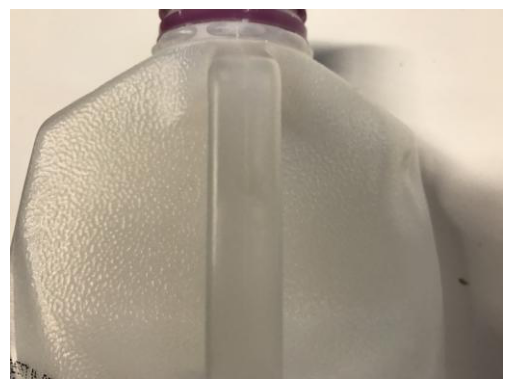

Actual Class: plastic
Image: plastic160.jpg


In [99]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

category = "plastic"   # keep it as plastic for now

img_name = random.choice(os.listdir(f"data_split/test/{category}"))
img_path = f"data_split/test/{category}/{img_name}"

img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

print("Actual Class:", category)
print("Image:", img_name)

In [101]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model3.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: plastic


In [103]:
import random

for i in range(5):

    actual_class = random.choice(class_names)

    img_name = random.choice(
        os.listdir(f"data_split/test/{actual_class}")
    )

    img_path = f"data_split/test/{actual_class}/{img_name}"

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model3.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    print(
        f"Actual: {actual_class} | Predicted: {predicted_class}"
    )

Actual: metal | Predicted: metal
Actual: trash | Predicted: trash
Actual: plastic | Predicted: plastic
Actual: paper | Predicted: paper
Actual: paper | Predicted: paper


In [105]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


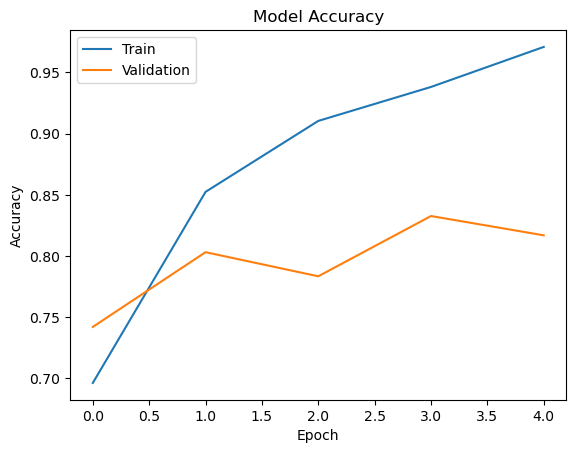

In [107]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()


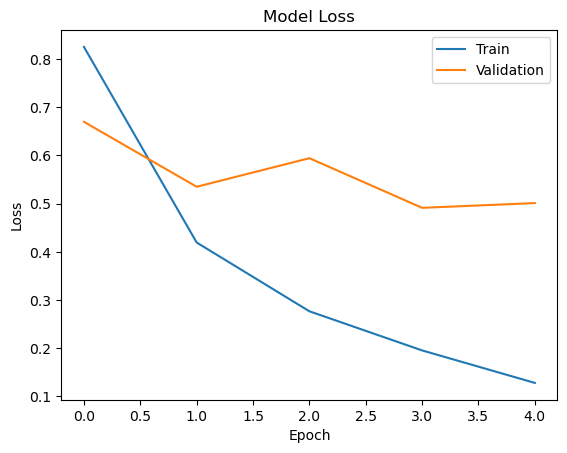

In [109]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [111]:
test_loss, test_accuracy = model3.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 567ms/step - accuracy: 0.7970 - loss: 0.5475
Test Accuracy: 0.8169291615486145
Test Loss: 0.5011516213417053


In [113]:
from tensorflow.keras.models import load_model

loaded_model = load_model("waste_classifier_mobilenet.keras")

print("Model loaded successfully")


Model loaded successfully


In [115]:
import os

os.makedirs("app", exist_ok=True)

print("App folder created")


App folder created
